# Projet d'Analyse de données



In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from skimpy import skim
import seaborn as sns 
import prince
from statsmodels.graphics.mosaicplot import mosaic
from pandas.plotting import scatter_matrix

%matplotlib inline

ModuleNotFoundError: No module named 'skimpy'

# Introduction


## Prise en charge et présentation du jeu de données 

In [2]:
# Liste des variables originales et leurs descriptions
variables = {
    "Date": "Date du jour de la donnée",
    "Service": "Type de service ou train",
    "Gare de départ": "Gare de départ",
    "Gare d'arrivée": "Gare d'arrivée",
    "Durée moyenne du trajet": "Durée moyenne du trajet",
    "Nombre de circulations prévues": "Nombre de circulations prévues",
    "Nombre de trains annulés": "Nombre de trains annulés",
    "Nombre de trains en retard au départ": "Nombre de trains en retard au départ",
    "Retard moyen des trains en retard au départ": "Retard moyen des trains en retard au départ",
    "Retard moyen de tous les trains au départ": "Retard moyen de tous les trains au départ",
    "Nombre de trains en retard à l'arrivée": "Nombre de trains en retard à l'arrivée",
    "Retard moyen des trains en retard à l'arrivée": "Retard moyen des trains en retard à l'arrivée",
    "Retard moyen de tous les trains à l'arrivée": "Retard moyen de tous les trains à l'arrivée",
    "Nombre trains en retard > 15min": "Nombre de trains en retard entre 15 et 30 min",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "Retard moyen > 15 min si concurrence aérienne",
    "Nombre trains en retard > 30min": "Nombre de trains en retard entre 30 et 60 min",
    "Nombre trains en retard > 60min": "Nombre de trains en retard de plus de 60 min",
    "Prct retard pour causes externes": "Pourcentage de retard pour causes externes",
    "Prct retard pour cause infrastructure": "Pourcentage de retard pour causes infrastructure",
    "Prct retard pour cause gestion trafic": "Pourcentage de retard pour causes gestion trafic",
    "Prct retard pour cause matériel roulant": "Pourcentage de retard pour causes matériel roulant",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "Pourcentage de retard pour causes gestion gare / réutilisation matériel",
    "Prct retard pour cause prise en compte voyageurs (affluence": "Pourcentage de retard pour causes affluence voyageurs"
}

# transformer noms plus courts
short_names = {
    "Date": "date",
    "Service": "service",
    "Gare de départ": "dep_station",
    "Gare d'arrivée": "arr_station",
    "Durée moyenne du trajet": "avg_duration",
    "Nombre de circulations prévues": "planned_trains",
    "Nombre de trains annulés": "cancelled_trains",
    "Nombre de trains en retard au départ": "dep_late_trains",
    "Retard moyen des trains en retard au départ": "dep_avg_late",
    "Retard moyen de tous les trains au départ": "dep_avg_all",
    "Nombre de trains en retard à l'arrivée": "arr_late_trains",
    "Retard moyen des trains en retard à l'arrivée": "arr_avg_late",
    "Retard moyen de tous les trains à l'arrivée": "arr_avg_all",
    "Nombre trains en retard > 15min": "late_15",
    "Retard moyen trains en retard > 15 (si liaison concurrencée par vol)": "late_15_air",
    "Nombre trains en retard > 30min": "late_30",
    "Nombre trains en retard > 60min": "late_60",
    "Prct retard pour causes externes": "pct_external",
    "Prct retard pour cause infrastructure": "pct_infra",
    "Prct retard pour cause gestion trafic": "pct_traffic",
    "Prct retard pour cause matériel roulant": "pct_rolling",
    "Prct retard pour cause gestion en gare et réutilisation de matériel": "pct_station",
    "Prct retard pour cause prise en compte voyageurs (affluence": "pct_passengers"
}

# création DataFrame pour affichage 
df_vars = pd.DataFrame({
    "Variables renommées": [short_names[k] for k in variables.keys()],
    "Description": [variables[k] for k in variables.keys()]
})

print("Chaque individu représente un mois, pour lesquels on observe 23 variables")
display(df_vars.style.set_properties(**{'text-align': 'left'}).set_table_styles(
    [dict(selector='th', props=[('text-align', 'left')])]
))


Chaque individu représente un mois, pour lesquels on observe 23 variables


,Variables renommées,Description
0,date,Date du jour de la donnée
1,service,Type de service ou train
2,dep_station,Gare de départ
3,arr_station,Gare d'arrivée
4,avg_duration,Durée moyenne du trajet
5,planned_trains,Nombre de circulations prévues
6,cancelled_trains,Nombre de trains annulés
7,dep_late_trains,Nombre de trains en retard au départ
8,dep_avg_late,Retard moyen des trains en retard au départ
9,dep_avg_all,Retard moyen de tous les trains au départ


In [3]:
data = pd.read_excel('regularite-mensuelle-tgv-aqst.ods',engine='odf')
data = data.rename(columns=short_names)


display( 
    data.head().style.background_gradient(cmap='BuPu')
)

c:\Users\alipe\miniconda3\envs\AD_project\Lib\site-packages\pandas\io\formats\style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
c:\Users\alipe\miniconda3\envs\AD_project\Lib\site-packages\pandas\io\formats\style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,Commentaire annulations,dep_late_trains,dep_avg_late,dep_avg_all,Commentaire retards au départ,arr_late_trains,arr_avg_late,arr_avg_all,Commentaire retards à l'arrivée,late_15,late_15_air,late_30,late_60,pct_external,pct_infra,pct_traffic,pct_rolling,pct_station,pct_passengers,gestions PSH,correspondances)
0,2025-01,International,GENEVE,PARIS LYON,193,238,1,nan,216,3.182485,2.979606,nan,19,42.776316,4.399015,nan,19,42.776316,0,13,10.000000,60.000000,20.000000,5.000000,5.000000,0.000000,nan,nan
1,2025-01,International,ITALIE,PARIS LYON,535,30,0,nan,14,2.713095,1.366667,nan,5,31.940000,8.500556,nan,5,31.940000,0,1,20.000000,0.000000,40.000000,40.000000,0.000000,0.000000,nan,nan
2,2025-01,National,BESANCON FRANCHE COMTE TGV,PARIS LYON,133,183,0,nan,30,17.588889,2.555373,nan,24,52.936111,6.397359,nan,20,60.764167,0,14,20.000000,48.000000,16.000000,12.000000,0.000000,4.000000,nan,nan
3,2025-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,145,1029,0,nan,317,18.564090,5.589828,nan,180,40.713704,8.774603,nan,132,50.812500,0,69,20.000000,20.555556,29.444444,16.111111,6.111111,7.777778,nan,nan
4,2025-01,National,BREST,PARIS MONTPARNASSE,232,294,7,nan,20,11.966667,0.835714,nan,30,37.223889,4.704413,nan,30,37.223889,0,13,32.258065,25.806452,16.129032,9.677419,9.677419,6.451613,nan,nan


In [4]:
data['moy_retard_train_deja_retard'] = np.where(
    data['dep_late_trains'] > 0, 
    (data['dep_avg_all'] * data['planned_trains']) / data['dep_late_trains'], 
    0  # Valeur par défaut si aucun train n'est en retard
)

In [5]:
data.dtypes

date                                   str
service                                str
dep_station                         object
arr_station                         object
avg_duration                         int64
planned_trains                       int64
cancelled_trains                     int64
Commentaire annulations            float64
dep_late_trains                      int64
dep_avg_late                       float64
dep_avg_all                        float64
Commentaire retards au départ      float64
arr_late_trains                      int64
arr_avg_late                       float64
arr_avg_all                        float64
Commentaire retards à l'arrivée    float64
late_15                              int64
late_15_air                        float64
late_30                              int64
late_60                              int64
pct_external                       float64
pct_infra                          float64
pct_traffic                        float64
pct_rolling

In [6]:
cols_to_drop = [
    c for c in data.columns 
    if c.startswith("Commentaire") 
    or " gestions PSH" in c 
    or "correspondances)" in c
]
data = data.drop(columns=cols_to_drop)
display(
    data.head().style.background_gradient(cmap="BuPu")
)
len(data)

data['date'] = data['date'].astype('category')
data['service'] = data['service'].astype('category')
data['dep_station'] = data['dep_station'].astype('category')
data['arr_station'] = data['arr_station'].astype('category')
skim(data)

,date,service,dep_station,arr_station,avg_duration,planned_trains,cancelled_trains,dep_late_trains,dep_avg_late,dep_avg_all,arr_late_trains,arr_avg_late,arr_avg_all,late_15,late_15_air,late_30,late_60,pct_external,pct_infra,pct_traffic,pct_rolling,pct_station,pct_passengers,moy_retard_train_deja_retard
0,2025-01,International,GENEVE,PARIS LYON,193,238,1,216,3.182485,2.979606,19,42.776316,4.399015,19,42.776316,0,13,10.000000,60.000000,20.000000,5.000000,5.000000,0.000000,3.283085
1,2025-01,International,ITALIE,PARIS LYON,535,30,0,14,2.713095,1.366667,5,31.940000,8.500556,5,31.940000,0,1,20.000000,0.000000,40.000000,40.000000,0.000000,0.000000,2.928571
2,2025-01,National,BESANCON FRANCHE COMTE TGV,PARIS LYON,133,183,0,30,17.588889,2.555373,24,52.936111,6.397359,20,60.764167,0,14,20.000000,48.000000,16.000000,12.000000,0.000000,4.000000,15.587778
3,2025-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,145,1029,0,317,18.564090,5.589828,180,40.713704,8.774603,132,50.812500,0,69,20.000000,20.555556,29.444444,16.111111,6.111111,7.777778,18.144900
4,2025-01,National,BREST,PARIS MONTPARNASSE,232,294,7,20,11.966667,0.835714,30,37.223889,4.704413,30,37.223889,0,13,32.258065,25.806452,16.129032,9.677419,9.677419,6.451613,12.285000


╭──────────────────────────────────────────────── skimpy summary ─────────────────────────────────────────────────╮
│          Data Summary                Data Types               Categories                                        │
│ ┏━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┓ ┏━━━━━━━━━━━━━┳━━━━━━━┓ ┏━━━━━━━━━━━━━━━━━━━━━━━┓                                │
│ ┃ Dataframe         ┃ Values ┃ ┃ Column Type ┃ Count ┃ ┃ Categorical Variables ┃                                │
│ ┡━━━━━━━━━━━━━━━━━━━╇━━━━━━━━┩ ┡━━━━━━━━━━━━━╇━━━━━━━┩ ┡━━━━━━━━━━━━━━━━━━━━━━━┩                                │
│ │ Number of rows    │ 1505   │ │ float64     │ 12    │ │ date                  │                                │
│ │ Number of columns │ 24     │ │ int64       │ 8     │ │ service               │                                │
│ └───────────────────┴────────┘ │ category    │ 4     │ │ dep_station           │                                │
│                                └─────────────┴───────┘ │ arr_station           │                                │
│                                                        └───────────────────────┘                                │
│                                                     number                                                      │
│ ┏━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━┳━━━━━━━┳━━━━━━━━┳━━━━━━━━┳━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━┳━━━━━━━━┓  │
│ ┃ column                 ┃ NA  ┃ NA %  ┃ mean   ┃ sd     ┃ p0      ┃ p25    ┃ p50   ┃ p75   ┃ p100  ┃ hist   ┃  │
│ ┡━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━╇━━━━━━━╇━━━━━━━━╇━━━━━━━━╇━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━╇━━━━━━━━┩  │
│ │      avg_duration      │   0 │     0 │  171.4 │  88.06 │      45 │     99 │   162 │   226 │   564 │ ▇▇▃▁▁  │  │
│ │     planned_trains     │   0 │     0 │  291.1 │  195.1 │       1 │    163 │   238 │   402 │  1097 │  ▆▇▃▁  │  │
│ │    cancelled_trains    │   0 │     0 │  2.227 │  5.439 │       0 │      0 │     1 │     2 │    79 │   ▇    │  │
│ │    dep_late_trains     │   0 │     0 │  79.04 │  83.78 │       0 │     20 │    44 │   112 │   596 │  ▇▂▁   │  │
│ │      dep_avg_late      │   0 │     0 │  15.38 │  11.63 │       0 │  9.102 │    13 │ 19.04 │ 178.3 │   ▇    │  │
│ │      dep_avg_all       │   0 │     0 │  3.595 │  6.302 │  -1.964 │  1.365 │ 2.629 │ 4.179 │   115 │   ▇    │  │
│ │    arr_late_trains     │   0 │     0 │  43.47 │   33.3 │       0 │     19 │    35 │    60 │   276 │  ▇▃▁   │  │
│ │      arr_avg_late      │   0 │     0 │  39.35 │  14.83 │       0 │  29.94 │  37.9 │ 47.09 │ 112.2 │  ▁▇▇▂  │  │
│ │      arr_avg_all       │   0 │     0 │  7.277 │   4.28 │  -3.327 │  4.231 │ 6.474 │ 9.299 │ 36.34 │  ▂▇▂   │  │
│ │        late_15         │   0 │     0 │  32.69 │  25.09 │       0 │     14 │    27 │    44 │   234 │  ▇▃▁   │  │
│ │      late_15_air       │   0 │     0 │  46.11 │  14.39 │       0 │  36.61 │    44 │ 53.76 │ 112.2 │   ▃▇▃  │  │
│ │        late_30         │   0 │     0 │  13.24 │  14.77 │     -44 │      1 │     9 │    20 │   124 │   ▇▆▁  │  │
│ │        late_60         │   0 │     0 │  8.923 │  8.373 │       0 │      3 │     6 │    13 │    69 │  ▇▂▁   │  │
│ │      pct_external      │   0 │     0 │  19.42 │   13.9 │       0 │  9.677 │ 17.39 │ 26.09 │   100 │  ▇▇▁   │  │
│ │       pct_infra        │   0 │     0 │  22.09 │  13.99 │       0 │  12.01 │ 20.69 │    30 │   100 │  ▇▇▂▁  │  │
│ │      pct_traffic       │   0 │     0 │  23.28 │   13.1 │       0 │  14.11 │ 22.22 │ 31.25 │   100 │  ▅▇▃   │  │
│ │      pct_rolling       │   0 │     0 │     18 │  12.51 │       0 │  10.34 │ 16.35 │ 23.96 │   100 │  ▇▇▁   │  │
│ │      pct_station       │   0 │     0 │  8.555 │  8.068 │       0 │  2.439 │ 7.207 │  12.6 │ 66.67 │   ▇▃   │  │
│ │     pct_passengers     │   0 │     0 │  7.733 │  6.978 │       0 │  2.703 │ 6.452 │ 11.43 │ 66.67 │   ▇▂   │  │
│ │ moy_retard_train_deja_ │   0 │     0 │  14.49 │  11.75 │  -27.76 │  8.444 │  12.2 │ 17.91 │ 173.2 │   ▁▇   │  │
│ │         retard         │     │       │        │     

# Réduction de dimension linéaire

## Qu'est ce qui pourrait, dans les variables qualitatives, expliquer le retard ? - MCA

Nos individus sont très déterminés par des variables qualitatives (Gare de départ, gare d'arrivée ...). Nous allons donc utiliser la MCA pour étudier les données.

Nous allons tenter de répondre à la question suivte : "Est-ce qu'on peut expliquer le retard 'un train en fonction de la date, du service, de la gare de départ et/ou de la gare d'arrivée ?"

Pour cela nous allons créer une variable qualitative prenant pour valeur 'Jamais', 'Rarement', 'Régulièrement', 'Souvent' en fonction de la proportion de retard sur une liaison et sur un mois.

In [22]:
proportion_retard = (data['arr_late_trains']+data['cancelled_trains']) / data['planned_trains']

bins = [-0.01, 0.05, 0.15, 0.40, 1.0]
labels = ['Jamais', 'Rarement', 'Régulièrement', 'Souvent']

data['retard'] = pd.cut(proportion_retard, bins=bins, labels=labels)

print(data['retard'].value_counts())

retard
Rarement         756
Régulièrement    685
Jamais            34
Souvent           30
Name: count, dtype: int64


In [23]:
df_mca=data.select_dtypes(include='category')
display(df_mca.head())

,date,service,dep_station,arr_station,retard
0,2025-01,International,GENEVE,PARIS LYON,Rarement
1,2025-01,International,ITALIE,PARIS LYON,Régulièrement
2,2025-01,National,BESANCON FRANCHE COMTE TGV,PARIS LYON,Rarement
3,2025-01,National,BORDEAUX ST JEAN,PARIS MONTPARNASSE,Régulièrement
4,2025-01,National,BREST,PARIS MONTPARNASSE,Rarement


<Figure size 1400x800 with 0 Axes>

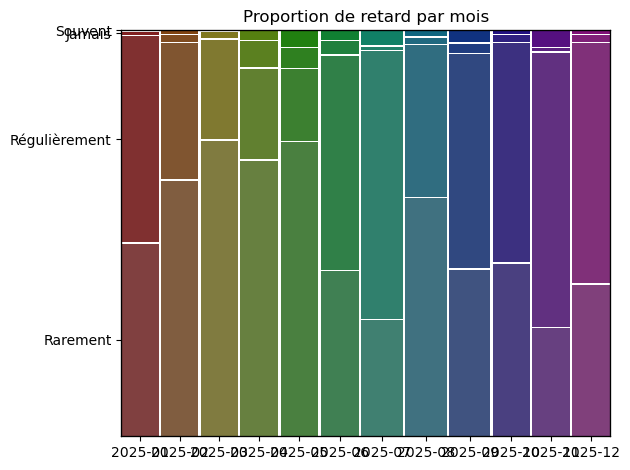

In [24]:
plt.figure(figsize=(14, 8))
mosaic(df_mca, ['date', 'retard'], 
       title='Proportion de retard par mois',
       labelizer=lambda k: "")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Le mois pour lequel il y a le plus de retard est le mois de juillet.

In [25]:
X = df_mca[['service', 'dep_station', 'arr_station']]

mca = prince.MCA(
    n_components=3,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

mca = mca.fit(X)

mca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.738,1.92%,1.92%
1,0.634,1.65%,3.58%
2,0.625,1.63%,5.21%


In [26]:
mca.column_contributions_.T.style.background_gradient(cmap='YlOrRd', axis=1).format('{:.0%}')

,service__International,service__National,dep_station__0,dep_station__AIX EN PROVENCE TGV,dep_station__ANGERS SAINT LAUD,dep_station__ANGOULEME,dep_station__ANNECY,dep_station__ARRAS,dep_station__AVIGNON TGV,dep_station__BARCELONA,dep_station__BELLEGARDE (AIN),dep_station__BESANCON FRANCHE COMTE TGV,dep_station__BORDEAUX ST JEAN,dep_station__BREST,dep_station__CHAMBERY CHALLES LES EAUX,dep_station__DIJON VILLE,dep_station__DOUAI,dep_station__DUNKERQUE,dep_station__FRANCFORT,dep_station__GENEVE,dep_station__GRENOBLE,dep_station__ITALIE,dep_station__LA ROCHELLE VILLE,dep_station__LAUSANNE,dep_station__LAVAL,dep_station__LE CREUSOT MONTCEAU MONTCHANIN,dep_station__LE MANS,dep_station__LILLE,dep_station__LYON PART DIEU,dep_station__MACON LOCHE,dep_station__MARNE LA VALLEE,dep_station__MARSEILLE ST CHARLES,dep_station__METZ,dep_station__MONTPELLIER,dep_station__MULHOUSE VILLE,dep_station__NANCY,dep_station__NANTES,dep_station__NICE VILLE,dep_station__NIMES,dep_station__PARIS EST,dep_station__PARIS LYON,dep_station__PARIS MONTPARNASSE,dep_station__PARIS NORD,dep_station__PERPIGNAN,dep_station__POITIERS,dep_station__QUIMPER,dep_station__REIMS,dep_station__RENNES,dep_station__SAINT ETIENNE CHATEAUCREUX,dep_station__ST MALO,dep_station__ST PIERRE DES CORPS,dep_station__STRASBOURG,dep_station__STUTTGART,dep_station__TOULON,dep_station__TOULOUSE MATABIAU,dep_station__TOURCOING,dep_station__TOURS,dep_station__VALENCE ALIXAN TGV,dep_station__VANNES,dep_station__ZURICH,arr_station__0,arr_station__AIX EN PROVENCE TGV,arr_station__ANGERS SAINT LAUD,arr_station__ANGOULEME,arr_station__ANNECY,arr_station__ARRAS,arr_station__AVIGNON TGV,arr_station__BARCELONA,arr_station__BELLEGARDE (AIN),arr_station__BESANCON FRANCHE COMTE TGV,arr_station__BORDEAUX ST JEAN,arr_station__BREST,arr_station__CHAMBERY CHALLES LES EAUX,arr_station__DIJON VILLE,arr_station__DOUAI,arr_station__DUNKERQUE,arr_station__FRANCFORT,arr_station__GENEVE,arr_station__GRENOBLE,arr_station__ITALIE,arr_station__LA ROCHELLE VILLE,arr_station__LAUSANNE,arr_station__LAVAL,arr_station__LE CREUSOT MONTCEAU MONTCHANIN,arr_station__LE MANS,arr_station__LILLE,arr_station__LYON PART DIEU,arr_station__MACON LOCHE,arr_station__MARNE LA VALLEE,arr_station__MARSEILLE ST CHARLES,arr_station__METZ,arr_station__MONTPELLIER,arr_station__MULHOUSE VILLE,arr_station__NANCY,arr_station__NANTES,arr_station__NICE VILLE,arr_station__NIMES,arr_station__PARIS EST,arr_station__PARIS LYON,arr_station__PARIS MONTPARNASSE,arr_station__PARIS NORD,arr_station__PERPIGNAN,arr_station__POITIERS,arr_station__QUIMPER,arr_station__REIMS,arr_station__RENNES,arr_station__SAINT ETIENNE CHATEAUCREUX,arr_station__ST MALO,arr_station__ST PIERRE DES CORPS,arr_station__STRASBOURG,arr_station__STUTTGART,arr_station__TOULON,arr_station__TOULOUSE MATABIAU,arr_station__TOURCOING,arr_station__TOURS,arr_station__VALENCE ALIXAN TGV,arr_station__VANNES,arr_station__ZURICH
0,24%,4%,0%,0%,0%,1%,0%,0%,0%,1%,0%,0%,1%,1%,0%,0%,0%,0%,3%,2%,0%,2%,1%,2%,0%,0%,0%,0%,1%,0%,0%,1%,1%,0%,0%,0%,0%,0%,0%,2%,1%,2%,0%,0%,0%,0%,0%,1%,0%,1%,0%,0%,3%,0%,0%,0%,0%,0%,0%,2%,0%,0%,0%,0%,0%,0%,0%,1%,0%,0%,0%,0%,0%,0%,0%,0%,2%,1%,0%,1%,0%,1%,0%,0%,1%,1%,1%,0%,1%,0%,0%,0%,0%,0%,0%,0%,0%,6%,6%,7%,0%,0%,0%,0%,0%,0%,0%,0%,0%,0%,2%,0%,0%,1%,0%,0%,0%,1%
1,0%,0%,0%,0%,0%,0%,0%,1%,0%,1%,1%,1%,1%,0%,1%,0%,2%,1%,1%,0%,0%,0%,0%,0%,0%,1%,0%,1%,0%,0%,0%,0%,1%,0%,0%,1%,1%,1%,0%,15%,1%,7%,1%,0%,1%,0%,1%,0%,0%,0%,0%,0%,0%,0%,0%,1%,0%,0%,0%,0%,0%,0%,1%,1%,0%,0%,0%,0%,0%,0%,2%,0%,0%,0%,0%,1%,3%,0%,0%,0%,0%,0%,0%,0%,1%,0%,0%,0%,0%,1%,3%,0%,0%,2%,1%,0%,0%,2%,9%,4%,6%,0%,0%,1%,3%,0%,0%,0%,0%,3%,3%,0%,1%,0%,0%,0%,0%,0%
2,0%,0%,0%,1%,0%,0%,1%,1%,1%,0%,1%,1%,1%,0%,0%,1%,4%,3%,1%,0%,0%,1%,0%,0%,0%,0%,0%,2%,0%,0%,1%,1%,0%,0%,1%,0%,1%,1%,0%,4%,11%,1%,2%,1%,1%,0%,0%,0%,0%,0%,0%,1%,1%,1%,0%,0%,0%,1%,0%,1%,1%,0%,0%,0%,0%,1%,0%,0%,1%,1%,0%,0%,1%,0%,0%,1%,1%,0%,0%,1%,0%,0%,0%,0%,0%,0%,1%,1%,1%,1%,1%,0%,1%,1%,0%,1%,0%,3%,11%,3%,9%,0%,0%,0%,0%,0%,1%,0%,0%,1%,0%,1%,0%,1%,0%,0%,0%,0%


On peut voir que c'est principalement la variable service_International qui contribut à l'axe 0, la variable dep_station_PARIS qui contribut à l'axe 1 et les variables arr_station_PARIS LYON et dep_station_PARIS LYON qui contribuent à l'axe 2.

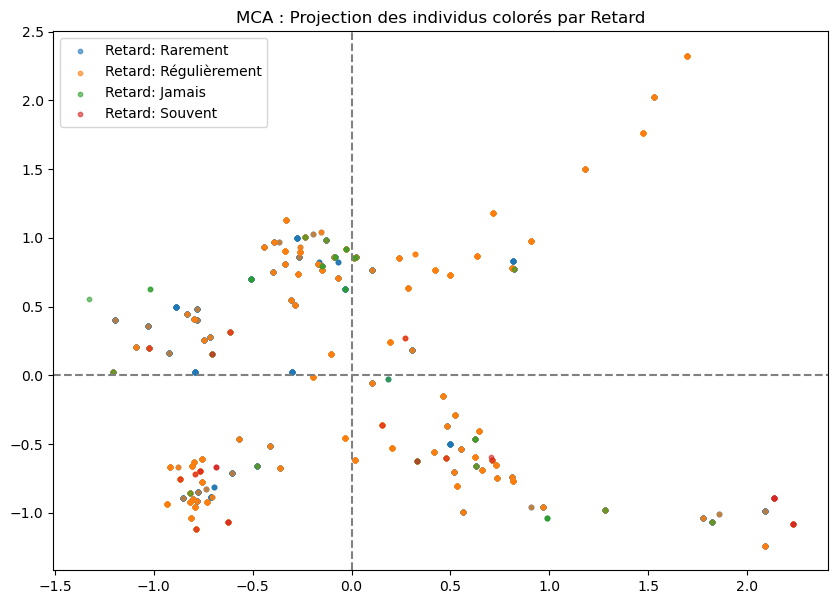

In [27]:
# Obtenir les coordonnées des lignes (individus)
row_coordinates = mca.row_coordinates(X)

# Tracer le graphique
plt.figure(figsize=(10, 7))
for val in df_mca['retard'].unique():
    mask = df_mca['retard'] == val
    plt.scatter(
        row_coordinates.loc[mask, 1], 
        row_coordinates.loc[mask, 2], 
        label=f"Retard: {val}",
        alpha=0.6,
        s=10
    )

plt.axhline(0, color='grey', linestyle='--')
plt.axvline(0, color='grey', linestyle='--')
plt.title("MCA : Projection des individus colorés par Retard")
plt.legend()
plt.show()

On remarque que les resultats de cette analyse ne sont pas interprétables.

**Demender quoi faire aux profs avec ça !**

## Qu'est ce qui pourrait, dans les variables qualitatives, expliquer le retard ? - ACP

Dans cette partie on va essayer d'expliquer la proportion de retard d'une autre manière. Pour se faire nous allons construire un plan ACP avec les variables quantitatives (hors pourcentages) et essayer de trouver des éléments qui expliqueraient le retard.

In [28]:
var_pca=["avg_duration", "planned_trains", "cancelled_trains", "dep_late_trains", "dep_avg_late", "dep_avg_all", "arr_avg_late", "arr_avg_all", "late_15", "late_15_air", "late_30", "late_60"]
df_pca = data[var_pca]
display(df_pca.head())

,avg_duration,planned_trains,cancelled_trains,dep_late_trains,dep_avg_late,dep_avg_all,arr_avg_late,arr_avg_all,late_15,late_15_air,late_30,late_60
0,193,238,1,216,3.182485,2.979606,42.776316,4.399015,19,42.776316,0,13
1,535,30,0,14,2.713095,1.366667,31.940000,8.500556,5,31.940000,0,1
2,133,183,0,30,17.588889,2.555373,52.936111,6.397359,20,60.764167,0,14
3,145,1029,0,317,18.564090,5.589828,40.713704,8.774603,132,50.812500,0,69
4,232,294,7,20,11.966667,0.835714,37.223889,4.704413,30,37.223889,0,13


In [29]:
pca = prince.PCA(
    n_components=10,
    n_iter=3,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=42
)

pca = pca.fit(df_pca)

display(pca.eigenvalues_summary)

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,3.819,31.82%,31.82%
1,2.697,22.47%,54.29%
2,1.360,11.34%,65.63%
3,1.057,8.81%,74.44%
4,0.991,8.26%,82.70%
5,0.611,5.09%,87.79%
6,0.569,4.74%,92.53%
7,0.458,3.81%,96.34%
8,0.162,1.35%,97.69%


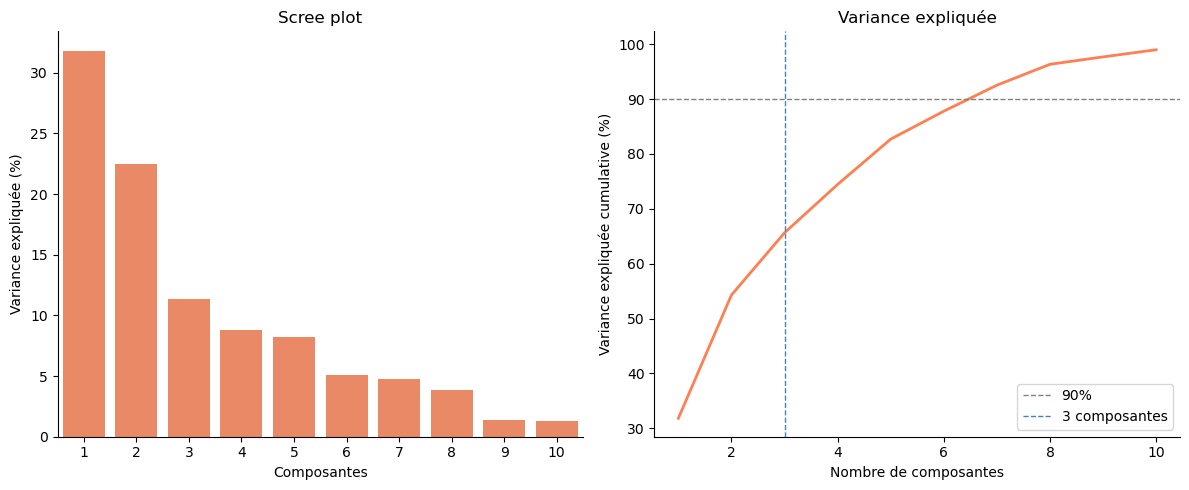

Variance expliquée par les 3 premières componsantes : 65.63%


In [38]:
explained_variance_ratio = pca.eigenvalues_summary['% of variance'].str.replace('%', '').astype(float)
n_bars = 10

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Scree plot
sns.barplot(x=np.arange(1, n_bars + 1), y=explained_variance_ratio[:n_bars],
            color="coral", ax=axes[0])
axes[0].set_xlabel("Composantes")
axes[0].set_ylabel("Variance expliquée (%)")
axes[0].set_title("Scree plot")
axes[0].spines[["top", "right"]].set_visible(False)

# Cumulative explained variance
cumvar = np.cumsum(explained_variance_ratio)
axes[1].plot(np.arange(1, len(cumvar) + 1), cumvar, color="coral", linewidth=2)
axes[1].axhline(90, color="gray", linestyle="--", linewidth=1, label="90%")
axes[1].axvline(3, color="steelblue", linestyle="--", linewidth=1, label="3 composantes")
axes[1].set_xlabel("Nombre de composantes")
axes[1].set_ylabel("Variance expliquée cumulative (%)")
axes[1].set_title("Variance expliquée")
axes[1].legend()
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print(f"Variance expliquée par les 3 premières componsantes : {cumvar[2]:.2f}%")

On remarque que la variance est mal expliquée par les premières composantes principales. On va choisir de représenter les 3 premières, tout en sachant qu'il faudra mettre en perspectives les resultats vu que seulement 65.63% de la variance sera expliquée.

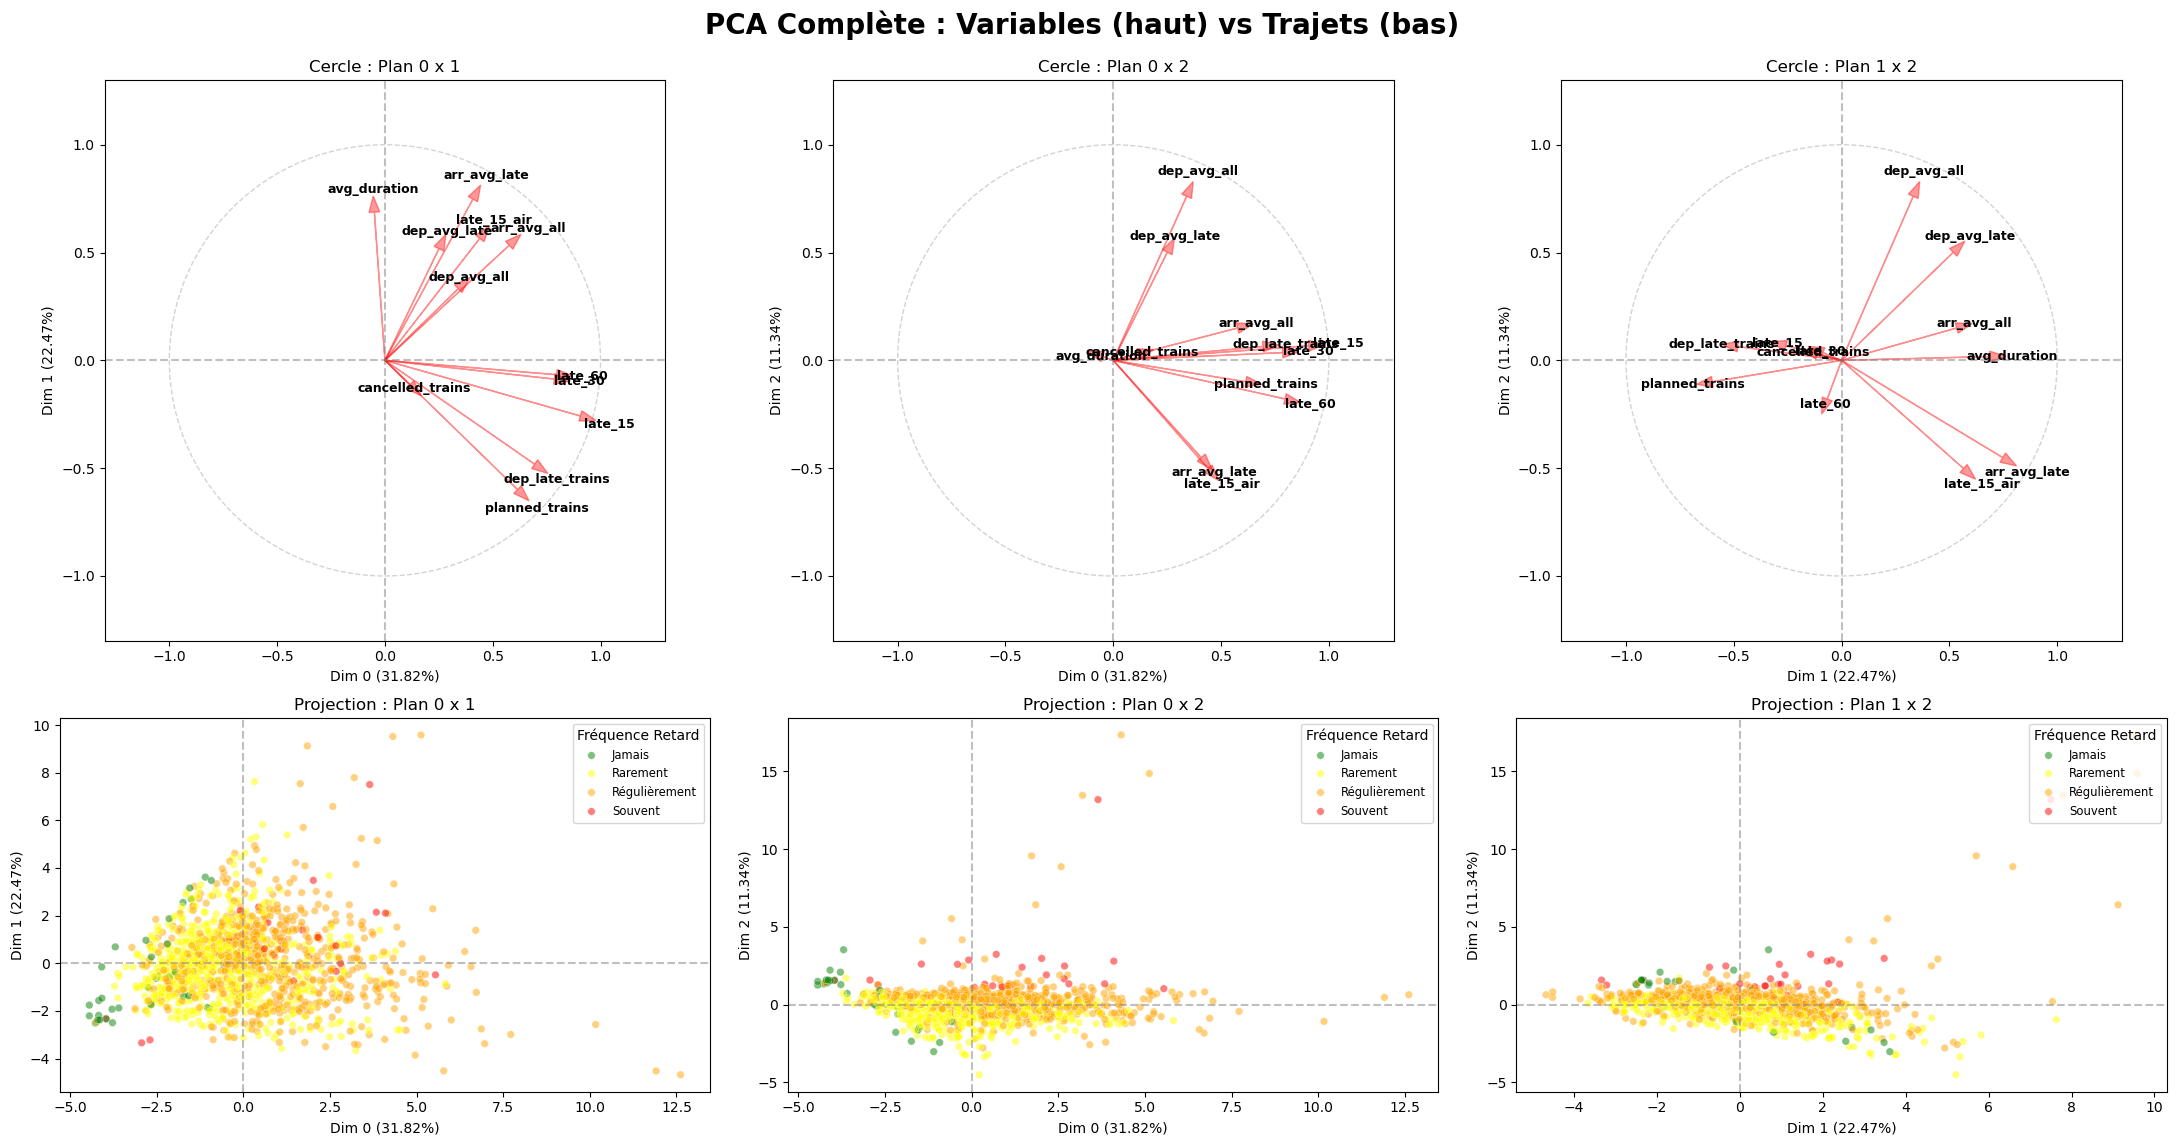

In [19]:
var_correlations = pca.column_correlations
coords = pca.row_coordinates(df_pca)
retard_col = data.loc[df_pca.index, 'retard']
pairs = [(0, 1), (0, 2), (1, 2)]
palette_retard = {'Jamais':'green', 'Rarement':'yellow', 'Régulièrement':'orange', 'Souvent': 'red'}

fig, axes = plt.subplots(2, 3, figsize=(22, 12), gridspec_kw={'height_ratios': [1.5, 1]})

for i, (dim_x, dim_y) in enumerate(pairs):
    ax_circle = axes[0, i]
    circle = plt.Circle((0,0), 1, color='lightgrey', fill=False, linestyle='--')
    ax_circle.add_artist(circle)
    
    for col in var_correlations.index:
        x = var_correlations.loc[col, dim_x]
        y = var_correlations.loc[col, dim_y]
        ax_circle.arrow(0, 0, x, y, color='r', alpha=0.4, head_width=0.05)
        ax_circle.text(x*1.15, y*1.15, col, color='black', ha='center', va='center', fontsize=9, fontweight='bold')

    ax_circle.set_xlim(-1.3, 1.3)
    ax_circle.set_ylim(-1.3, 1.3)
    ax_circle.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax_circle.axvline(0, color='grey', linestyle='--', alpha=0.5)
    
    var_x = pca.eigenvalues_summary.loc[dim_x, '% of variance']
    var_y = pca.eigenvalues_summary.loc[dim_y, '% of variance']
    
    ax_circle.set_title(f"Cercle : Plan {dim_x} x {dim_y}")
    ax_circle.set_xlabel(f"Dim {dim_x} ({var_x})")
    ax_circle.set_ylabel(f"Dim {dim_y} ({var_y})")
    ax_circle.set_aspect('equal')

    ax_proj = axes[1, i]
    sns.scatterplot(
        x=coords[dim_x], 
        y=coords[dim_y], 
        hue=retard_col, 
        palette=palette_retard,
        hue_order=['Jamais', 'Rarement', 'Régulièrement', 'Souvent'],
        alpha=0.5, 
        s=30, 
        ax=ax_proj
    )
    ax_proj.set_title(f"Projection : Plan {dim_x} x {dim_y}")
    ax_proj.set_xlabel(f"Dim {dim_x} ({var_x})")
    ax_proj.set_ylabel(f"Dim {dim_y} ({var_y})")
    ax_proj.axhline(0, color='grey', linestyle='--', alpha=0.5)
    ax_proj.axvline(0, color='grey', linestyle='--', alpha=0.5)
    ax_proj.legend(title='Fréquence Retard', loc='upper right', fontsize='small')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.suptitle("PCA Complète : Variables (haut) vs Trajets (bas)", fontsize=20, fontweight='bold')
plt.show()

**Faire interprétation, j'ai le cerveau embrummé**

# Méthodes de clustering

# 1. Méthode des k-means

# 2. Méthode des Hierarchical Agglomerative Clustering (HAC)

# 3. Méthode des Spectral clustering

# 4. Méthode des Gaussian Mixture Models (GMM)

# 5. Méthode des Stochastic Bloc Model (SBM)

# Réduction de dimension non-linéaire